In [1]:
import os
import numpy as np
import pathlib
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.layers import Rescaling, Dense, Flatten, MaxPool2D, Conv2D, Input
from tensorflow.data import AUTOTUNE, Dataset
from tensorflow.keras import Sequential
from tensorflow.keras.losses import SparseCategoricalCrossentropy

In [2]:
data_dir = pathlib.Path(r'data\flower_photos')
data_dir

WindowsPath('data/flower_photos')

In [3]:
image_count = len(list(data_dir.glob('*/*.jpg')))
image_count

3670

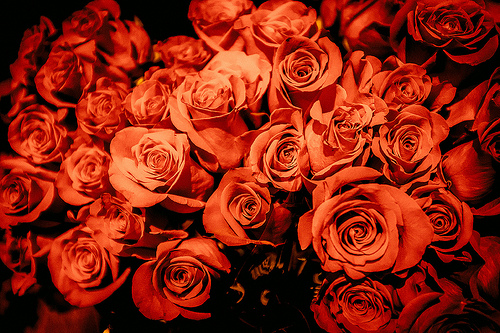

In [4]:
roses = list(data_dir.glob('roses/*'))
Image.open(str(roses[2]))

In [5]:
batch_size = 32
image_height, image_width = 180, 180

In [6]:
train_ds = image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset='training',
    batch_size=batch_size,
    seed=123,
    image_size=(image_height, image_width),
)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.


In [7]:
val_ds = image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset='validation',
    batch_size=batch_size,
    seed=123,
    image_size=(image_height, image_width),
)

Found 3670 files belonging to 5 classes.


Using 734 files for validation.


In [8]:
class_names = train_ds.class_names

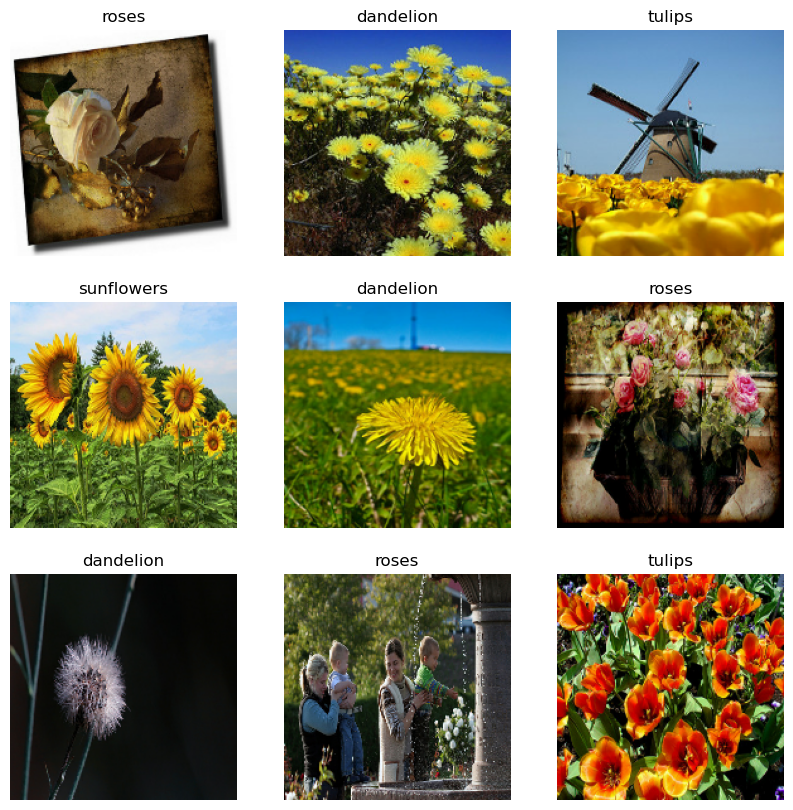

In [9]:
plt.figure(figsize=(10, 10))

for img, label in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i+1)
        plt.imshow(img[i].numpy().astype('uint8'))
        plt.title(class_names[label[i]])
        plt.axis('off')

In [10]:
normalization_layer = Rescaling(1./255.)

In [11]:
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [12]:
num_classes = 5
model = Sequential([
    Input(shape=(180, 180, 3)),
    normalization_layer,
    Conv2D(32, 3, activation='relu'),
    MaxPool2D(),
    Conv2D(32, 3, activation='relu'),
    MaxPool2D(),
    Conv2D(32, 3, activation='relu'),
    MaxPool2D(),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(num_classes)
])

In [24]:
model.compile(
    optimizer='adam',
    loss=SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [19]:
model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100
)

Epoch 1/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 175ms/step - accuracy: 0.4005 - loss: 1.3813 - val_accuracy: 0.5736 - val_loss: 1.1044
Epoch 2/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 151ms/step - accuracy: 0.5824 - loss: 1.0563 - val_accuracy: 0.5899 - val_loss: 1.0224
Epoch 3/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 155ms/step - accuracy: 0.6434 - loss: 0.9232 - val_accuracy: 0.6240 - val_loss: 0.9558
Epoch 4/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 155ms/step - accuracy: 0.7129 - loss: 0.7561 - val_accuracy: 0.6458 - val_loss: 0.9126
Epoch 5/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 152ms/step - accuracy: 0.7844 - loss: 0.5879 - val_accuracy: 0.6322 - val_loss: 0.9910
Epoch 6/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 153ms/step - accuracy: 0.8403 - loss: 0.4538 - val_accuracy: 0.6785 - val_loss: 0.9562
Epoch 7/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 15s 160ms/step - accuracy: 0.8658 - loss: 0.3739 - val_accuracy: 0.6362 - val_loss: 1.0718
Epoch 8/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 15s 161ms/step - accuracy: 0.8992 - loss: 0.2759 - 

KeyboardInterrupt: 

In [13]:
list_ds = Dataset.list_files(str(data_dir/'*/*'), shuffle=False)
list_ds = list_ds.shuffle(image_count, reshuffle_each_iteration=True)

In [14]:
class_names = np.array(sorted(
    [item.name for item in data_dir.glob('*') if item.name != 'LICENSE.txt']))
class_names

array(['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips'],
      dtype='<U10')

In [15]:
val_size = int(image_count * 0.2)
train_ds = list_ds.skip(val_size)
val_ds = list_ds.take(val_size)

In [16]:
def get_label(file_path):
    parts = tf.strings.split(file_path, os.path.sep)
    print(parts)
    one_hot = parts[-2] == class_names
    return tf.argmax(one_hot)

In [17]:
def decode_img(img):
    img = tf.io.decode_jpeg(img, channels=3)
    return tf.image.resize(img, [image_height, image_width])

In [18]:
def process_path(file_path):
    label = get_label(file_path)
    img = tf.io.read_file(file_path)
    img = decode_img(img)
    return img, label

In [19]:
train_ds = train_ds.map(process_path, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.map(process_path, num_parallel_calls=AUTOTUNE)

Tensor("StringSplit/RaggedGetItem/strided_slice_5:0", shape=(None,), dtype=string)
Tensor("StringSplit/RaggedGetItem/strided_slice_5:0", shape=(None,), dtype=string)


In [20]:
for image, label in train_ds.take(1):
    print("Image shape: ", image.numpy().shape)
    print("Label: ", label.numpy())

Image shape:  (180, 180, 3)
Label:  3


In [21]:
def configure_for_performance(ds):
    ds = ds.cache()
    ds = ds.shuffle(buffer_size=1000)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(buffer_size=AUTOTUNE)
    return ds


train_ds = configure_for_performance(train_ds)
val_ds = configure_for_performance(val_ds)

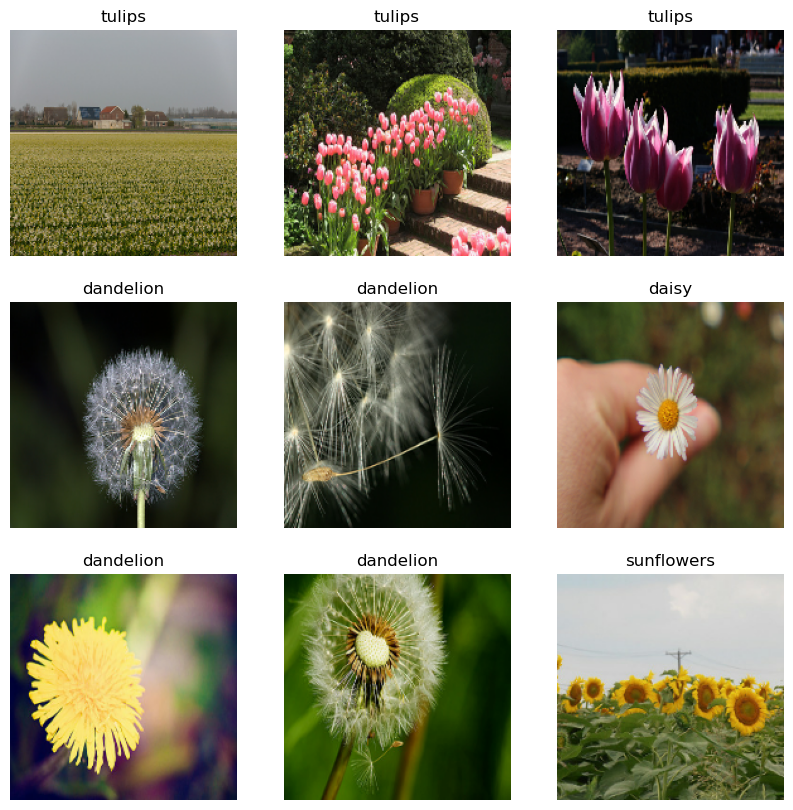

In [22]:
image_batch, label_batch = next(iter(train_ds))

plt.figure(figsize=(10, 10))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(image_batch[i].numpy().astype("uint8"))
    label = label_batch[i]
    plt.title(class_names[label])
    plt.axis("off")

In [25]:
model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 167ms/step - accuracy: 0.4189 - loss: 1.3171 - val_accuracy: 0.5777 - val_loss: 1.0425
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 157ms/step - accuracy: 0.5565 - loss: 1.0791 - val_accuracy: 0.6158 - val_loss: 0.9879
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 15s 165ms/step - accuracy: 0.6332 - loss: 0.9360 - val_accuracy: 0.7125 - val_loss: 0.8142
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 15s 161ms/step - accuracy: 0.6958 - loss: 0.7968 - val_accuracy: 0.7098 - val_loss: 0.7683
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 156ms/step - accuracy: 0.7721 - loss: 0.6349 - val_accuracy: 0.7684 - val_loss: 0.6574
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 156ms/step - accuracy: 0.8277 - loss: 0.4895 - val_accuracy: 0.8188 - val_loss: 0.5370
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 156ms/step - accuracy: 0.8920 - loss: 0.3200 - val_accuracy: 0.8529 - val_loss: 0.4767
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 15s 167ms/step - accuracy: 0.9343 - loss: 0.1963 - val_accu